In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
from google.colab import files

uploaded = files.upload()

Saving spam.csv to spam (1).csv


In [3]:
data = pd.read_csv("spam.csv", encoding="latin-1")

print(data.head())

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [4]:
data = data[['v1', 'v2']]

data.columns = ['label', 'message']

print(data.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [5]:
print(data.shape)
print(data['label'].value_counts())

(5572, 2)
label
ham     4825
spam     747
Name: count, dtype: int64


In [6]:
data['label'] = data['label'].map({'ham': 0, 'spam': 1})

print(data.head())

   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


In [7]:
X = data['message']
y = data['label']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 4457
Testing data: 1115


In [9]:
tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(4457, 7701)
(1115, 7701)


In [19]:
model = LogisticRegression(class_weight='balanced')

model.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced')

In [20]:
y_pred = model.predict(X_test_tfidf)

In [21]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100, "%")

Accuracy: 0.9838565022421525
Accuracy percentage: 98.38565022421525 %


In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.95      0.93      0.94       149

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



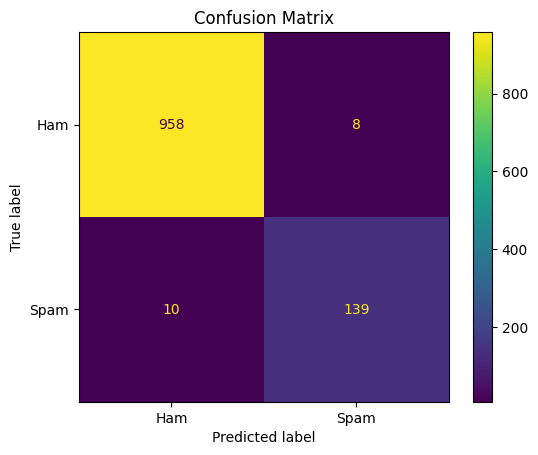

In [23]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Ham', 'Spam']
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [25]:
message = ["Hey, are we meeting at 5 pm today?"]

message_tfidf = tfidf.transform(message)

prediction = model.predict(message_tfidf)

if prediction[0] == 1:
    print("SPAM 🚨")
else:
    print("HAM ✅")

HAM ✅


In [26]:
messages = [
    "Congratulations! You have won a free iPhone. Click now!",
    "Hey, are we meeting at 5 pm today?",
    "URGENT! You have won a cash prize. Claim it now!",
    "Can you send me the notes from today's class?",
    "Get 50% discount on your next purchase. Click here!"
]

messages_tfidf = tfidf.transform(messages)
predictions = model.predict(messages_tfidf)

for msg, pred in zip(messages, predictions):
    result = "SPAM 🚨" if pred == 1 else "HAM ✅"
    print(result, "→", msg)

SPAM 🚨 → Congratulations! You have won a free iPhone. Click now!
HAM ✅ → Hey, are we meeting at 5 pm today?
SPAM 🚨 → URGENT! You have won a cash prize. Claim it now!
HAM ✅ → Can you send me the notes from today's class?
SPAM 🚨 → Get 50% discount on your next purchase. Click here!


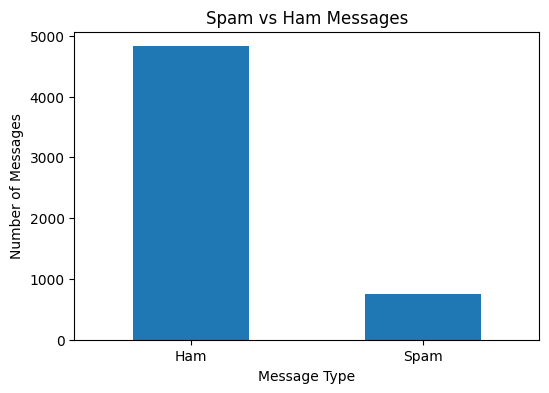

In [27]:
plt.figure(figsize=(6, 4))

data['label'].value_counts().plot(kind='bar')

plt.title("Spam vs Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")
plt.xticks([0, 1], ["Ham", "Spam"], rotation=0)

plt.show()

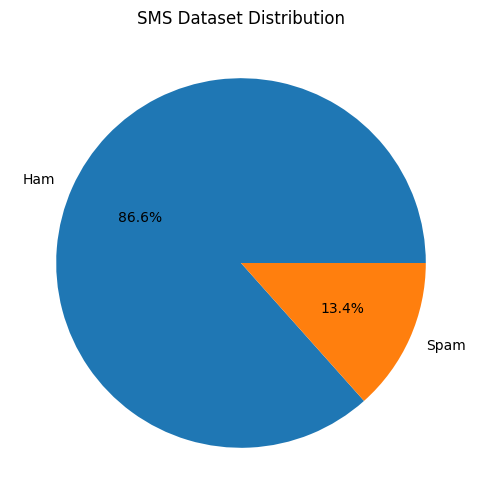

In [28]:
plt.figure(figsize=(6, 6))

data['label'].value_counts().plot(
    kind='pie',
    labels=['Ham', 'Spam'],
    autopct='%1.1f%%'
)

plt.title("SMS Dataset Distribution")
plt.ylabel("")

plt.show()

In [29]:
message = input("Enter your SMS: ")

message_tfidf = tfidf.transform([message])

prediction = model.predict(message_tfidf)

if prediction[0] == 1:
    print("🚨 SPAM MESSAGE")
else:
    print("✅ HAM (LEGITIMATE MESSAGE)")

Enter your SMS: hello will meet tomorrow at 7pm
✅ HAM (LEGITIMATE MESSAGE)


In [30]:
import joblib

joblib.dump(model, "spam_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [31]:
import os

print(os.listdir())

['.config', 'tfidf_vectorizer.pkl', 'spam_model.pkl', 'spam.csv', 'spam (1).csv', 'sample_data']


In [32]:
from google.colab import files

files.download("spam_model.pkl")
files.download("tfidf_vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>